## Importing Necessary Libraries

In [1]:
import os
from time import perf_counter as clock             # measuring the runtime for spectral fitting
from importlib import resources                    # to get built in templates
from urllib import request                         # download files from internet
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u

from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib                        # build model galaxy spectra

print("Libraries are printed!")

Libraries are printed!


## Printing the Header

In [2]:
ppxf_dir = resources.files('ppxf')                  # Defining ppxf path
fits_path ='data/spectra/2MASX_J01135716plus0022171_NED.fits'
hdul = fits.open(fits_path)

hdul.info()

print(repr(hdul[0].header))
#print(repr(hdul[1].header))
#print(repr(hdul[2].header))

Filename: data/spectra/2MASX_J01135716plus0022171_NED.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     222   (3861, 5)   float32   
SIMPLE  =                    T                                                  
BITPIX  =                  -32                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 3861                                                  
NAXIS2  =                    5                                                  
EXTEND  =                    T /                                                
TAI     =        4475038948.82 / 1st row - Number of seconds since Nov 17 1858  
RA      =            18.270861 / 1st row - Right ascension of telescope boresigh
DEC     =            0.016878  / 1st row - Declination of telescope boresight (d
EQUINOX =              2000.00 /                                                
RADE

## Fixing Scales and Plotting the Spectrum

In [8]:
t = hdul[0].data                                  # Loading the Table of Final Spectrum
redshift = hdul[0].header['Z']      # SDSS redshift estimate
flux = t[:, 0]
loglam = t[:, 3]

galaxy = t['flux']/np.median(t['flux'])          # Normalization
ln_lam_gal = t['loglam']*np.log(10)      
lam_gal = np.exp(ln_lam_gal)                     # Wavelength in Angstroms (log sampled)

print(galaxy.shape)
print(lam_gal[:5])
print(redshift)

plt.figure(figsize=(12,6))
plt.plot(lam_gal, galaxy)
plt.title("Primary Galaxy Spectrum")
plt.xlabel("Wavelengths in Angstrom")
plt.ylabel("Normalized Flux")
plt.grid(True)
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

(3861,)
[3791.40344183 3792.27654525 3793.14984974 3794.02335533 3794.89706208]
0.0454276


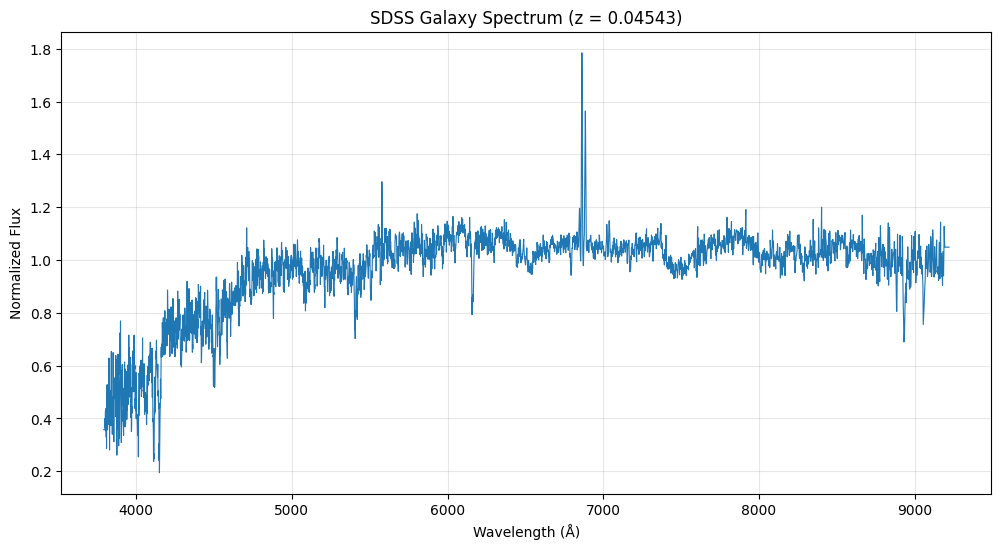

In [18]:
t = hdul[0].data

flux = t[0, :]
flux = np.where(np.isfinite(flux), flux, np.nan)
n = t.shape[1]
loglam = 3.5788 + 1e-4 * np.arange(n)
lam = 10**loglam

# normalize
galaxy = flux / np.nanmedian(flux)

z = hdul[0].header['Z']

print(galaxy.shape)
print(lam[:5])
print(z)

mask = np.isfinite(lam) & np.isfinite(galaxy)

plt.figure(figsize=(12,6))
plt.plot(lam[mask], galaxy[mask], lw=0.8)

plt.title(f"SDSS Galaxy Spectrum (z = {z:.5f})")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.grid(True, alpha=0.3)

plt.show()

## Further Cleaning Data

In [23]:
lam_gal = util.vac_to_air(lam_gal)              # fixing wavelengths in air and vaccum
print(t.shape)
print(t)

t = hdul[0].data 
ivar = t['ivar']

noise = np.zeros_like(ivar, dtype=float)

valid = ivar > 0
noise[valid] = 1 / np.sqrt(ivar[valid])
noise[~valid] = 0.0163

c = 299792.458                                                         # speed of light in km/s
d_ln_lam_gal = (ln_lam_gal[-1] - ln_lam_gal[0])/(ln_lam_gal.size - 1)  # Use full lam range for accuracy
velscale = c*d_ln_lam_gal    

dlam_gal = np.gradient(lam_gal)                                        # Size of every pixel in Angstroms
wdisp = t['wdisp']                                                     # Instrumental dispersion of every pixel, in pixels units
fwhm_gal = 2.355*wdisp*dlam_gal                                        # Resolution FWHM of every pixel, in Angstroms

(5, 3861)
[[ 1.3873700e+01  1.3871600e+01  1.3869500e+01 ...  4.0678398e+01
   4.0678200e+01  4.0678001e+01]
 [-3.5794363e+00 -3.5400572e+00 -3.5981913e+00 ...  2.7294464e+00
   2.7393608e+00  2.7652054e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.6777216e+07  1.6777216e+07  1.6777216e+07 ...  1.6777216e+07
   1.6777216e+07  1.6777216e+07]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]]


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## Setup the Steller Templates

In [ ]:
sps_name = 'emiles'                                                     #galaxev,fsps,xsl

basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename
if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)

fwhm_gal_dic = {"lam": lam_gal, "fwhm": fwhm_gal}
sps = lib.sps_lib(filename, velscale, fwhm_gal_dic)

stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)

In [ ]:
lam_range_gal = np.array([np.min(lam_gal), np.max(lam_gal)])/(1 + redshift)
gas_templates, gas_names, gas_wave = \
    util.emission_lines(sps.ln_lam_temp, lam_range_gal, fwhm_gal_dic)

In [ ]:
templates = np.column_stack([stars_templates, gas_templates])

n_temps = stars_templates.shape[1]

## pPXF Fitting

In [ ]:
vel0 = c*np.log(1 + redshift)
sol = [vel0, 200]


component = [0]*n_temps  # Single stellar kinematic component=0 for all templates
component += [1]*8
component += [2, 2, 3, 3, 4, 5, 6, 7, 8]
component = np.array(component)

moments = [2]*9

start = [sol for j in range(len(moments))]
tied = [['', ''] for j in range(len(moments))]
for j in range(3, len(moments)):
    tied[j][0] = 'p[4]'

In [ ]:
#          V0 s0 V1 s1 V2 s2 V3 s3 V4 s4 V5 s5 V6 s6 V7 s7 V8 s8
A_ineq = [[0, -2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # -2*s0 + s1 < 0 => s1 < 2*s0
          [0, -2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # s2 < 2*s0
          [0, -2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # s3 < 2*s0
          [0, -2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # s4 < 2*s0
          [0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # s5 < 2*s0
          [0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # s6 < 2*s0
          [0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # s7 < 2*s0
          [0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]  # s8 < 2*s0
b_ineq = [0, 0, 0, 0, 0, 0, 0, 0]
constr_kinem = {"A_ineq": A_ineq, "b_ineq": b_ineq}

In [ ]:
degree= -1
mdegree = 10
t = clock()
pp = ppxf(templates, galaxy, noise, velscale, start, plot=False,
            moments=moments, degree=degree, mdegree=mdegree, 
            lam=lam_gal, component=component, tied=tied, 
            gas_component=component > 0, gas_names=gas_names,
            constr_kinem=constr_kinem, lam_temp=sps.lam_temp)
print(f"Elapsed time in pPXF: {(clock() - t):.2f}")

## Galaxy Spectrum after Fitting

In [ ]:
model = pp.bestfit                                                     # pp.plot() for quick visualization
galaxy_flux = galaxy

residual = galaxy_flux - model

plt.figure(figsize=(12, 6))

plt.plot(lam_gal, galaxy_flux, label="Observed", linewidth=1)
plt.plot(lam_gal, model, label="pPXF Model", linewidth=1)
plt.plot(lam_gal, residual, label="Residual", linewidth=1)

plt.xlabel("Wavelength")
plt.ylabel("Relative Flux")
plt.title(f"pPXF fit with {sps_name} SPS templates")
plt.legend()
plt.show()

## Emission Line Measurements

In [ ]:
for name, wave in zip(gas_names, gas_wave):
    print(f"{name:15s}  {wave:.2f} Å")

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(lam_gal, galaxy, label="Observed", linewidth=1)
plt.plot(lam_gal, pp.bestfit, label="Model", linewidth=1)

line_obs_waves = np.array(gas_wave) * (1 + redshift)

colors = plt.cm.tab20(np.linspace(0, 1, len(gas_names)))

for name, wave, color in zip(gas_names, line_obs_waves, colors):
    plt.axvline(wave, color=color, linestyle='--', alpha=0.8, label=name)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=8, ncol=2)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Relative Flux")
plt.title("Spectrum with Emission Lines")
plt.show()